In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pickle
import pandas as pd
import os
import math

In [2]:
class WarehouseRobotEnv(gym.Env):
    def __init__(self, stochastic=False):
        super(WarehouseRobotEnv, self).__init__()

        self.grid_size = 6  # 6x6 Grid
        self.obstacles = [(2, 2), (3, 3), (4, 1)]  # Fixed shelves
        self.pickup_location = (3, 2)
        self.dropoff_location = (5, 5)
        self.robot_position = (0, 0)  # Start position
        self.has_item = False  # Whether the robot has picked up an item
        self.stochastic = stochastic  # Determines environment randomness
        self.visited_positions = []  # Track visited positions

        # Load images
        self.robot_img = mpimg.imread("agent.png")
        self.pickup_img = mpimg.imread("pickup.png")
        self.dropoff_img = mpimg.imread("dropoff.png")
        self.obstacle_img = mpimg.imread("obstacles.png")
        # Define action space: [Up, Down, Left, Right, Pick-up, Drop-off]
        self.action_space = spaces.Discrete(6)

        # Observation space: (Position X, Position Y, Has item (0 or 1))
        self.observation_space = spaces.Tuple((
            spaces.Discrete(self.grid_size),
            spaces.Discrete(self.grid_size),
            spaces.Discrete(2)  # 0: No item, 1: Holding item
        ))

    def step(self, action):
        x, y = self.robot_position
        reward = -1  # Penalize steps for efficiency
        terminated = False
        truncated = False
        info = {}

        if action == 0:  # Up
            new_position = (x, y - 1)
        elif action == 1:  # Down
            new_position = (x, y + 1)
        elif action == 2:  # Left
            new_position = (x - 1, y)
        elif action == 3:  # Right
            new_position = (x + 1, y)
        elif action == 4 and self.robot_position == self.pickup_location and not self.has_item:
            self.has_item = True
            reward = 25
            new_position = self.robot_position
        elif action == 5 and self.robot_position == self.dropoff_location and self.has_item:
            reward = 100
            terminated = True
            new_position = self.robot_position
        else:
            new_position = self.robot_position

        # Ensure within bounds
        if new_position[0] < 0 or new_position[0] >= self.grid_size or new_position[1] < 0 or new_position[1] >= self.grid_size:
            new_position = self.robot_position  # No movement

        # Prevent moving into obstacles
        if new_position in self.obstacles:
            reward -= 20  # Penalty for hitting an obstacle
            new_position = self.robot_position

        # Stochastic environment: 10% chance of staying in place
        if self.stochastic and random.random() < 0.1:
            new_position = self.robot_position

        self.visited_positions.append(self.robot_position)  # Track visited positions
        self.robot_position = new_position
        observation = (*self.robot_position, int(self.has_item))


        return observation , reward, terminated, truncated, info

    def reset(self):
        self.robot_position = (0, 0)
        self.has_item = False
        self.visited_positions.clear()
        observation = (*self.robot_position, int(self.has_item))
        info = {}
        return observation, info

    def render(self):
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(-0.5, self.grid_size-0.5)
        ax.set_ylim(-0.5, self.grid_size-0.5)

        for ox, oy in self.obstacles:
            print("\n")
            ax.imshow(self.obstacle_img, extent=[ox-0.5, ox+0.5, oy-0.5, oy+0.5])

        if not self.has_item:
            ax.imshow(self.pickup_img, extent=[self.pickup_location[0]-0.5, self.pickup_location[0]+0.5, self.pickup_location[1]-0.5, self.pickup_location[1]+0.5])

        ax.imshow(self.dropoff_img, extent=[self.dropoff_location[0]-0.5, self.dropoff_location[0]+0.5, self.dropoff_location[1]-0.5, self.dropoff_location[1]+0.5])
        print("\n")
        ax.imshow(self.robot_img, extent=[self.robot_position[0]-0.5, self.robot_position[0]+0.5, self.robot_position[1]-0.5, self.robot_position[1]+0.5])
        print("\n")
        for pos in self.visited_positions:
            ax.add_patch(plt.Circle((pos[0], pos[1]), 0.2, color='blue', alpha=0.3))

        plt.grid(True)
        plt.title("Warehouse Robot Environment")
        plt.show()



In [3]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

# Q-Network architecture
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Experience Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

# DQN Agent Environment
class DQNAgent:
    def __init__(self, env, state_dim, action_dim, buffer_size=10000, batch_size=64, gamma=0.99, lr=1e-3, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, target_update=10):
        self.env = env
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.batch_size = batch_size
        self.gamma = gamma
        self.lr = lr
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.target_update = target_update

        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)
        self.steps_done = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        state = torch.tensor([state], dtype=torch.float32)
        with torch.no_grad():
            return self.policy_net(state).argmax().item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        state, action, reward, next_state, done = self.memory.sample(self.batch_size)

        state = torch.tensor(state, dtype=torch.float32)
        action = torch.tensor(action, dtype=torch.int64).unsqueeze(1)
        reward = torch.tensor(reward, dtype=torch.float32).unsqueeze(1)
        next_state = torch.tensor(next_state, dtype=torch.float32)
        done = torch.tensor(done, dtype=torch.float32).unsqueeze(1)

        q_values = self.policy_net(state).gather(1, action)
        next_q_values = self.target_net(next_state).max(1)[0].unsqueeze(1)
        expected_q = reward + (1 - done) * self.gamma * next_q_values

        loss = nn.functional.mse_loss(q_values, expected_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def train(self, episodes):
        rewards_per_episode = []
        epsilons = []

        for episode in range(episodes):
            state, _ = self.env.reset()
            state = self._flatten_state(state)
            total_reward = 0
            done = False
            steps = 0

            while not done and steps < 100:
                action = self.select_action(state)
                next_state, reward, done, _, _ = self.env.step(action)
                next_state = self._flatten_state(next_state)
                self.memory.push(state, action, reward, next_state, done)
                state = next_state

                self.train_step()
                total_reward += reward
                steps +=1


            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
            epsilons.append(self.epsilon)

            if episode % self.target_update == 0:
                self.target_net.load_state_dict(self.policy_net.state_dict())

            rewards_per_episode.append(total_reward)
            print(f"Episode {episode}, Reward: {total_reward}, Epsilon: {self.epsilon:.3f}")

        env_name = getattr(self.env, "spec", None)
        env_id = env_name.id if env_name is not None else "WarehouseRobot"
        torch.save(self.policy_net.state_dict(), f"dqn_{env_id}_weights.pth")

        return rewards_per_episode, epsilons



    def _flatten_state(self, state):
        return np.array(state, dtype=np.float32)


In [4]:
env =  WarehouseRobotEnv()
state_dim = 3
action_dim = env.action_space.n

agent = DQNAgent(env, state_dim, action_dim)
rewards, epsilons = agent.train(episodes=500)#episodes set to 500
print("Model weights saved to dqn_warehouse_weights.pth")

Episode 0, Reward: -154, Epsilon: 0.995
Episode 1, Reward: -260, Epsilon: 0.990


<ipython-input-3-337abec3f80e>:63: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  state = torch.tensor([state], dtype=torch.float32)


Episode 2, Reward: -140, Epsilon: 0.985
Episode 3, Reward: -160, Epsilon: 0.980
Episode 4, Reward: -140, Epsilon: 0.975
Episode 5, Reward: -220, Epsilon: 0.970
Episode 6, Reward: -220, Epsilon: 0.966
Episode 7, Reward: -120, Epsilon: 0.961
Episode 8, Reward: -380, Epsilon: 0.956
Episode 9, Reward: -260, Epsilon: 0.951
Episode 10, Reward: -220, Epsilon: 0.946
Episode 11, Reward: -180, Epsilon: 0.942
Episode 12, Reward: -320, Epsilon: 0.937
Episode 13, Reward: -120, Epsilon: 0.932
Episode 14, Reward: -140, Epsilon: 0.928
Episode 15, Reward: -180, Epsilon: 0.923
Episode 16, Reward: -74, Epsilon: 0.918
Episode 17, Reward: -240, Epsilon: 0.914
Episode 18, Reward: -100, Epsilon: 0.909
Episode 19, Reward: -61, Epsilon: 0.905
Episode 20, Reward: -120, Epsilon: 0.900
Episode 21, Reward: -280, Epsilon: 0.896
Episode 22, Reward: -120, Epsilon: 0.891
Episode 23, Reward: -220, Epsilon: 0.887
Episode 24, Reward: -200, Epsilon: 0.882
Episode 25, Reward: -234, Epsilon: 0.878
Episode 26, Reward: -134, 

In [5]:
# Load pretrained weights
agent.policy_net.load_state_dict(torch.load("dqn_WarehouseRobot_weights.pth"))
agent.policy_net.eval()  # Set to evaluation mode
print("Model weights loaded.")


Model weights loaded.


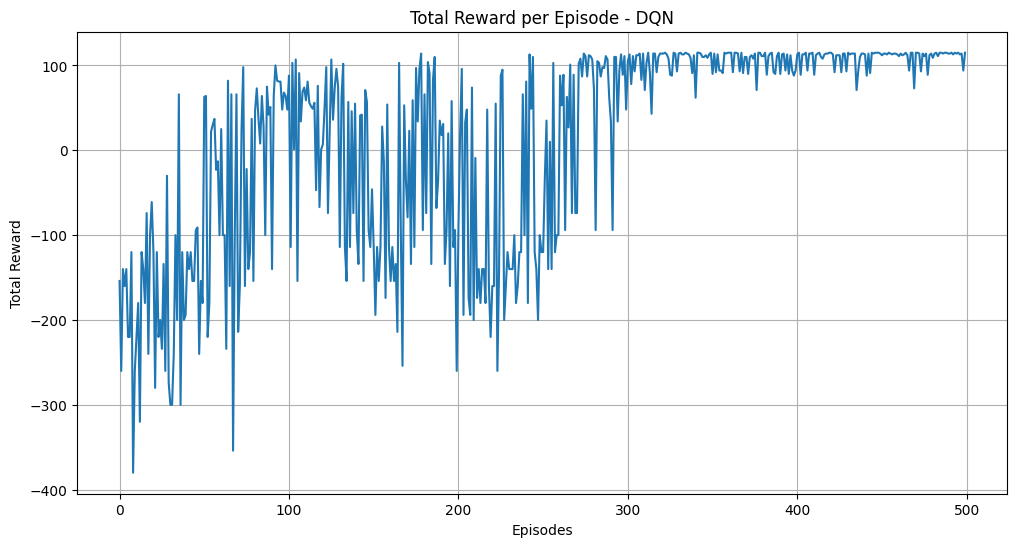

In [6]:
plt.figure(figsize=(12, 6))#plotting reward per episodes DQN
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode - DQN")
plt.grid()
plt.show()


In [7]:
agent.epsilon = 0.0  # greedy
for episode in range(5):
    state, _ = env.reset()
    state = agent._flatten_state(state)
    done = False
    total_reward = 0
    steps = 0
    max_steps = 200  # safety cutoff

    while not done and steps < max_steps:
        action = agent.select_action(state)
        next_state, reward, done, _, _ = env.step(action)
        state = agent._flatten_state(next_state)
        total_reward += reward
        steps += 1

    print(f"Greedy Episode {episode+1} Reward:", total_reward)


Greedy Episode 1 Reward: 115
Greedy Episode 2 Reward: 115
Greedy Episode 3 Reward: 115
Greedy Episode 4 Reward: 115
Greedy Episode 5 Reward: 115


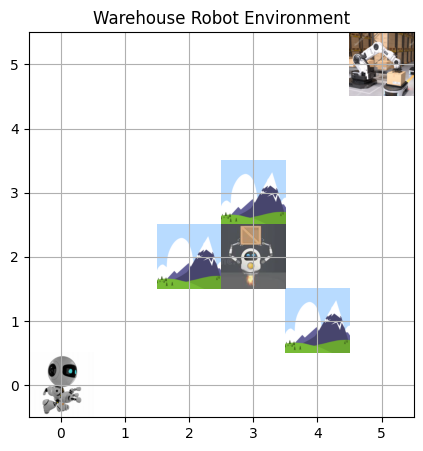

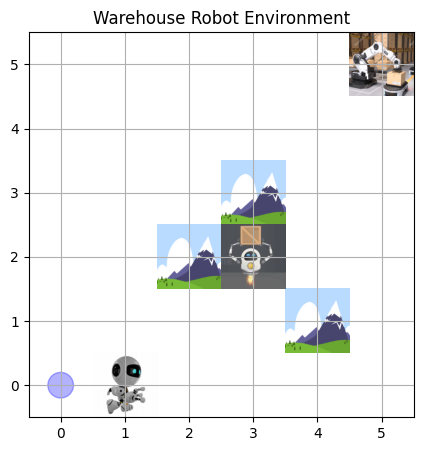

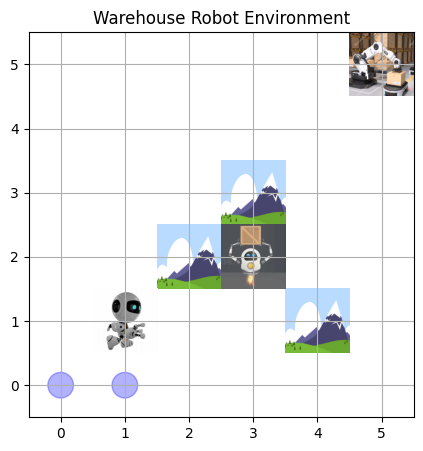

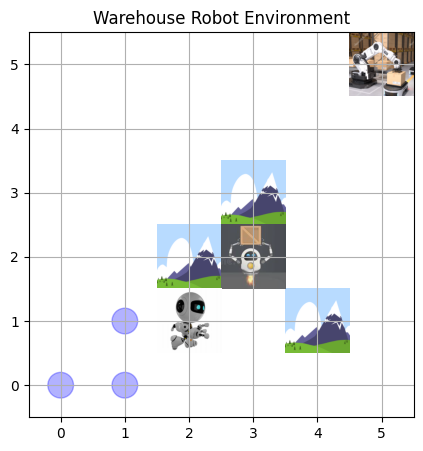

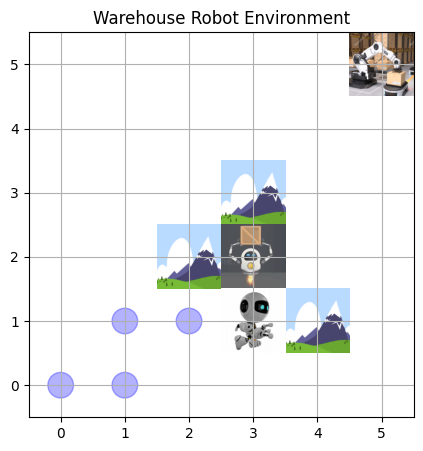

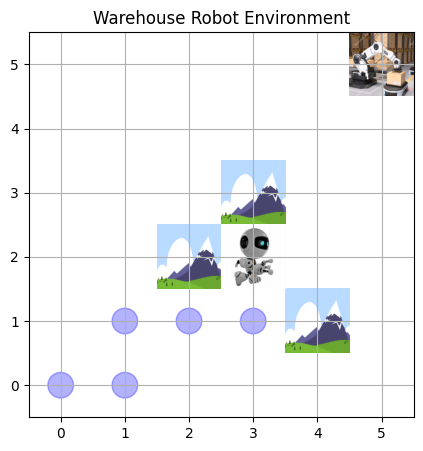

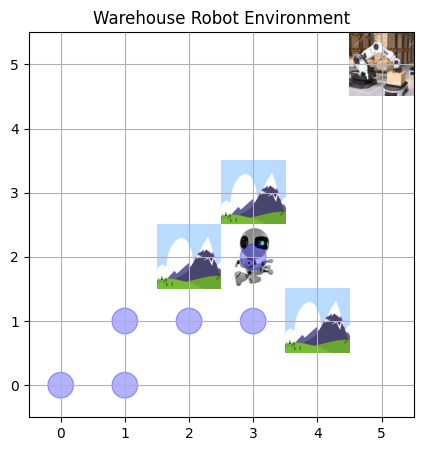

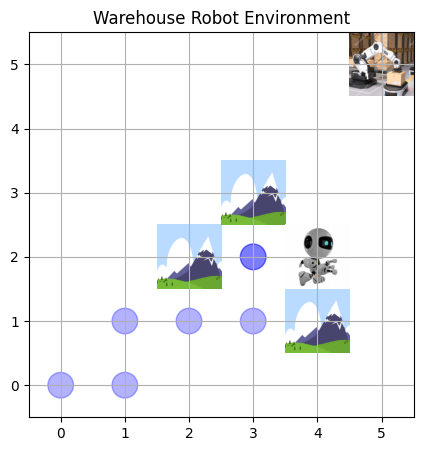

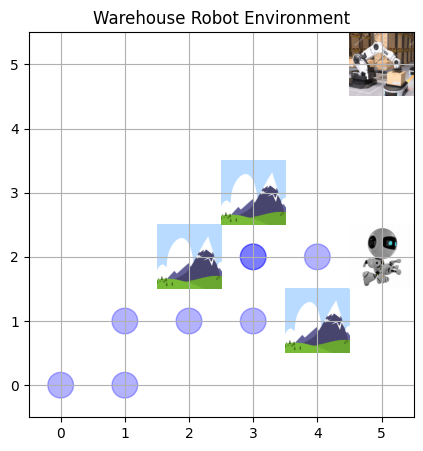

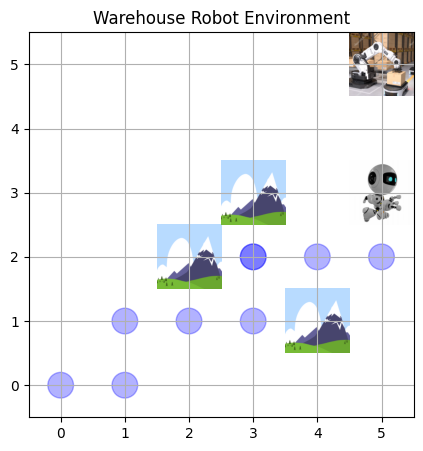

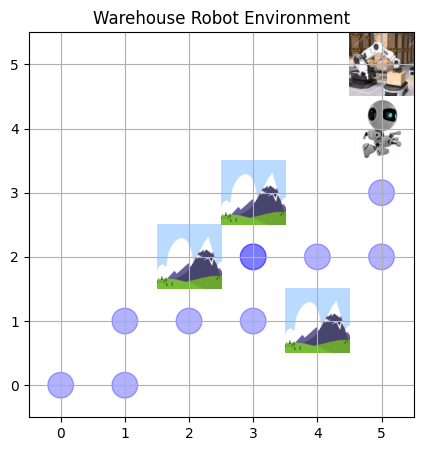

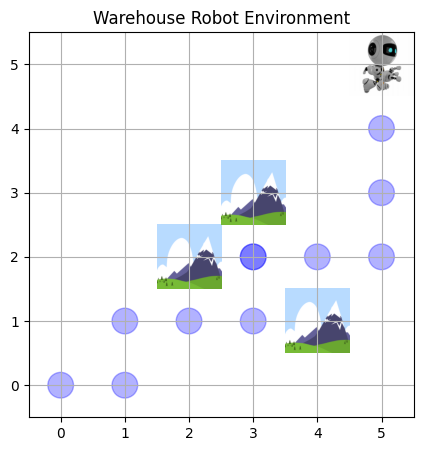

In [8]:
state, _ = env.reset()
state = agent._flatten_state(state)
done = False
while not done:
    env.render()
    action = agent.select_action(state)
    next_state, reward, done, _, _ = env.step(action)
    state = agent._flatten_state(next_state)


Model weights loaded.
Episode 1, Total Reward: 115
Episode 2, Total Reward: 115
Episode 3, Total Reward: 115
Episode 4, Total Reward: 115
Episode 5, Total Reward: 115


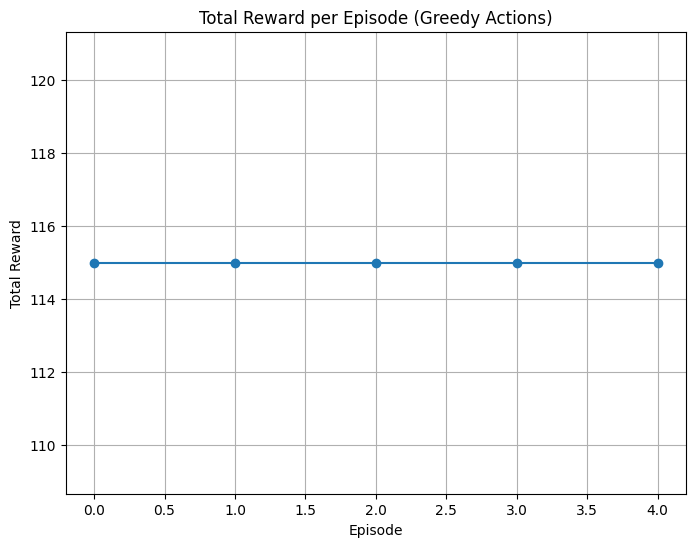

In [9]:
# Loading pretrained weights
agent.policy_net.load_state_dict(torch.load("dqn_WarehouseRobot_weights.pth"))
agent.policy_net.eval()  #evaluation mode
print("Model weights loaded.")

# Run 5 episodes with greedy actions
total_rewards = []
for episode in range(5):
    state, _ = env.reset()
    state = agent._flatten_state(state)
    total_reward = 0
    done = False
    while not done:
        # Select action greedily
        with torch.no_grad():
            action = agent.policy_net(torch.tensor([state], dtype=torch.float32)).argmax().item()
        next_state, reward, done, _, _ = env.step(action)
        next_state = agent._flatten_state(next_state)
        state = next_state
        total_reward += reward
    total_rewards.append(total_reward)
    print(f"Episode {episode + 1}, Total Reward: {total_reward}")

#total rewards per episode
plt.figure(figsize=(8, 6))
plt.plot(total_rewards, marker='o')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (Greedy Actions)")
plt.grid(True)
plt.show()

Episode 0, Reward: 29.0, Epsilon: 0.995
Episode 1, Reward: 47.0, Epsilon: 0.990
Episode 2, Reward: 11.0, Epsilon: 0.985
Episode 3, Reward: 15.0, Epsilon: 0.980
Episode 4, Reward: 17.0, Epsilon: 0.975
Episode 5, Reward: 24.0, Epsilon: 0.970
Episode 6, Reward: 33.0, Epsilon: 0.966
Episode 7, Reward: 39.0, Epsilon: 0.961
Episode 8, Reward: 20.0, Epsilon: 0.956
Episode 9, Reward: 31.0, Epsilon: 0.951
Episode 10, Reward: 25.0, Epsilon: 0.946
Episode 11, Reward: 19.0, Epsilon: 0.942
Episode 12, Reward: 14.0, Epsilon: 0.937
Episode 13, Reward: 15.0, Epsilon: 0.932
Episode 14, Reward: 25.0, Epsilon: 0.928
Episode 15, Reward: 15.0, Epsilon: 0.923
Episode 16, Reward: 37.0, Epsilon: 0.918
Episode 17, Reward: 11.0, Epsilon: 0.914
Episode 18, Reward: 13.0, Epsilon: 0.909
Episode 19, Reward: 16.0, Epsilon: 0.905
Episode 20, Reward: 13.0, Epsilon: 0.900
Episode 21, Reward: 25.0, Epsilon: 0.896
Episode 22, Reward: 26.0, Epsilon: 0.891
Episode 23, Reward: 17.0, Epsilon: 0.887
Episode 24, Reward: 27.0, 

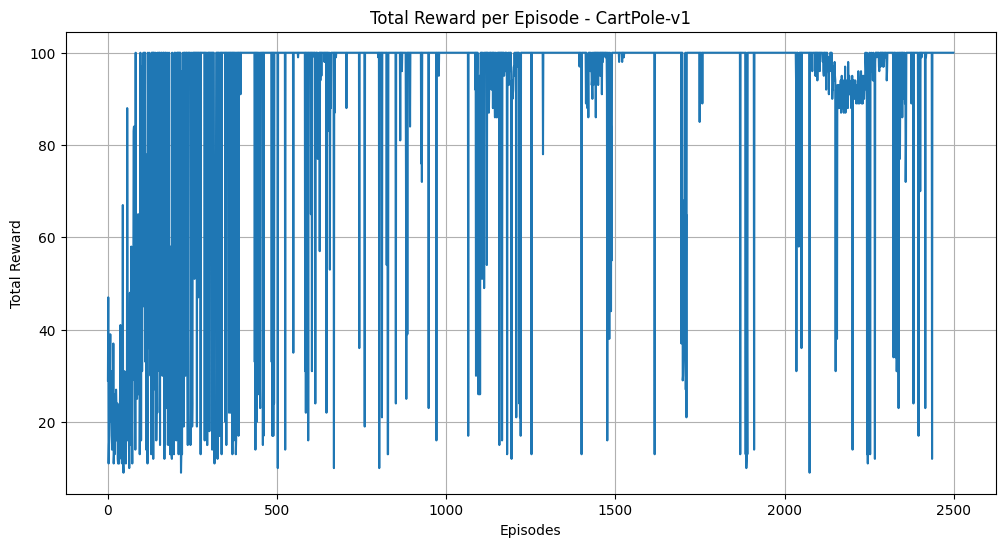

In [10]:
#CartPole environment
cartpole_env = gym.make('CartPole-v1')
state_dim = cartpole_env.observation_space.shape[0]
action_dim = cartpole_env.action_space.n

# New-agent for CartPole
cartpole_agent = DQNAgent(cartpole_env, state_dim, action_dim)

# Flatten function for CartPole
cartpole_agent._flatten_state = lambda s: np.array(s, dtype=np.float32)

# Training
cartpole_rewards, cartpole_epsilons = cartpole_agent.train(episodes=2500)

# Plotting cartPole reward per episode
plt.figure(figsize=(12, 6))
plt.plot(cartpole_rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode - CartPole-v1")
plt.grid()
plt.show()

In [11]:
# Evaluate average reward
cartpole_agent.epsilon = 0.0  # greedy
eval_rewards = []
for _ in range(10):
    state, _ = cartpole_env.reset(seed = 42)
    state = cartpole_agent._flatten_state(state)
    done = False
    total_reward = 0
    while not done:
        action = cartpole_agent.select_action(state)
        next_state, reward, done, _, _ = cartpole_env.step(action)
        state = cartpole_agent._flatten_state(next_state)
        total_reward += reward
    eval_rewards.append(total_reward)

print("Average Reward on Evaluation (CartPole):", np.mean(eval_rewards))


Average Reward on Evaluation (CartPole): 296.0


Episode 1, Reward: 290.0
Episode 2, Reward: 280.0
Episode 3, Reward: 277.0
Episode 4, Reward: 298.0
Episode 5, Reward: 268.0


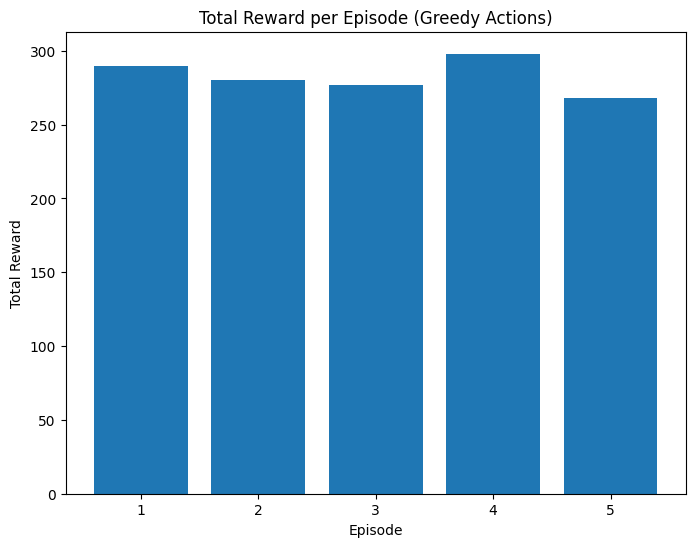

In [12]:
#for 5 episodes with greedy actions
cartpole_agent.epsilon = 0.0  # Set epsilon to 0 for greedy actions
greedy_rewards1 = []
for episode in range(5):
    state, _ = cartpole_env.reset()
    state = cartpole_agent._flatten_state(state)
    done = False
    total_reward = 0
    while not done:
        action = cartpole_agent.select_action(state)
        next_state, reward, done, _, _ = cartpole_env.step(action)
        state = cartpole_agent._flatten_state(next_state)
        total_reward += reward
    greedy_rewards1.append(total_reward)
    print(f"Episode {episode+1}, Reward: {total_reward}")

plt.figure(figsize=(8, 6))
plt.bar(range(1, 6), greedy_rewards1)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (Greedy Actions)")
plt.show()

In [13]:
!apt-get install -y swig


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 29 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 2s (520 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 126209 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubunt

In [14]:
!pip install "gymnasium[box2d]"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.8 MB/s eta 0:00:00
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp311-cp311-linux_x86_64.whl size=2351175 sha256=738a45972fb329bc47f64f2c9934f52b31c8da6e49b3d541f27b9bbf89b2a49b
  Stored in directory: /root/.cache/pip/wheels/ab/f1/0c/d56f4a2bdd12bae0a0693ec33f2f0daadb5eb9753c78fa5308
Successfully built box2d-py


Episode 0, Reward: -136.36, Epsilon: 0.990
Episode 1, Reward: -173.50, Epsilon: 0.980
Episode 2, Reward: -129.06, Epsilon: 0.970
Episode 3, Reward: -276.07, Epsilon: 0.961
Episode 4, Reward: -142.35, Epsilon: 0.951
Episode 5, Reward: -280.95, Epsilon: 0.942
Episode 6, Reward: -216.40, Epsilon: 0.932
Episode 7, Reward: -139.75, Epsilon: 0.923
Episode 8, Reward: -4.41, Epsilon: 0.914
Episode 9, Reward: -106.13, Epsilon: 0.905
Episode 10, Reward: -83.06, Epsilon: 0.896
Episode 11, Reward: -464.53, Epsilon: 0.887
Episode 12, Reward: -304.67, Epsilon: 0.878
Episode 13, Reward: -79.93, Epsilon: 0.869
Episode 14, Reward: -19.30, Epsilon: 0.860
Episode 15, Reward: -112.70, Epsilon: 0.852
Episode 16, Reward: -56.57, Epsilon: 0.843
Episode 17, Reward: -171.54, Epsilon: 0.835
Episode 18, Reward: -74.97, Epsilon: 0.827
Episode 19, Reward: -180.82, Epsilon: 0.818
Episode 20, Reward: -120.15, Epsilon: 0.810
Episode 21, Reward: -98.92, Epsilon: 0.802
Episode 22, Reward: -123.17, Epsilon: 0.794
Episod

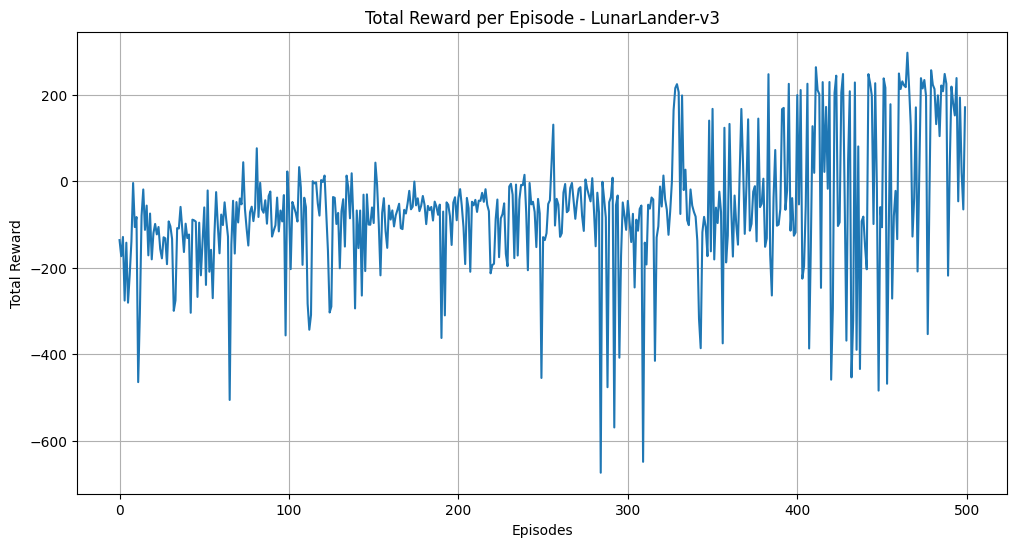

In [15]:
# Initialize LunarLander-v3
lander_env20 = gym.make('LunarLander-v3')
state_dim = lander_env20.observation_space.shape[0]
action_dim = lander_env20.action_space.n

# new DQN agent
lander_agent20 = DQNAgent(lander_env20, state_dim, action_dim)
lander_agent20._flatten_state = lambda s: np.array(s, dtype=np.float32)

# train function with max_steps
def train_lander(agent, env, episodes=500, max_steps=1000):
    rewards_per_episode = []
    epsilons = []

    for episode in range(episodes):
        state, _ = env.reset()
        state = agent._flatten_state(state)
        total_reward = 0
        done = False
        steps = 0

        while not done and steps < max_steps:
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            next_state = agent._flatten_state(next_state)

            agent.memory.push(state, action, reward, next_state, done)
            state = next_state

            agent.train_step()
            total_reward += reward
            steps += 1
        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
        epsilons.append(agent.epsilon)
        if steps == max_steps:
            print(f"Episode {episode} truncated after {max_steps} steps.")

        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

        if episode % agent.target_update == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())

        rewards_per_episode.append(total_reward)
        print(f"Episode {episode}, Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.3f}")

    return rewards_per_episode, epsilons

# Train the agent
lander_rewards, lander_epsilons = train_lander(lander_agent20, lander_env20, episodes=500)

# Plotting reward dynamics
plt.figure(figsize=(12, 6))
plt.plot(lander_rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode - LunarLander-v3")
plt.grid()
plt.show()


Episode 1, Reward: 153.27382741511147
Episode 2, Reward: 242.56921304990644
Episode 3, Reward: 4.578305469603961
Episode 4, Reward: 177.59692642158222
Episode 5, Reward: 177.21792379688617


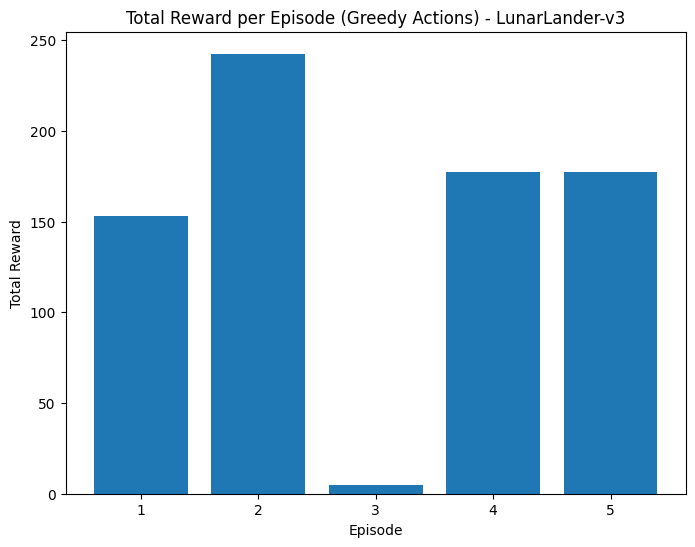

In [16]:
lander_agent20.epsilon = 0.0  # epsilon = 0 for greedy actions
greedy_rewards2 = []
for episode in range(5):
    state, _ = lander_env20.reset()
    state = lander_agent20._flatten_state(state)
    done = False
    total_reward = 0
    while not done:
        action = lander_agent20.select_action(state)
        next_state, reward, done, _, _ = lander_env20.step(action)
        state = lander_agent20._flatten_state(next_state)
        total_reward += reward
    greedy_rewards2.append(total_reward)
    print(f"Episode {episode+1}, Reward: {total_reward}")

plt.figure(figsize=(8, 6))
plt.bar(range(1, 6), greedy_rewards2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Total Reward per Episode (Greedy Actions) - LunarLander-v3")
plt.show()

In [17]:
def plot_training_results(rewards, epsilons, title_prefix):
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    axs[0].plot(rewards)
    axs[0].set_title(f"{title_prefix} - Total Reward per Episode")
    axs[0].set_xlabel("Episode")
    axs[0].set_ylabel("Total Reward")
    axs[0].grid()

    axs[1].plot(epsilons)
    axs[1].set_title(f"{title_prefix} - Epsilon Decay")
    axs[1].set_xlabel("Episode")
    axs[1].set_ylabel("Epsilon")
    axs[1].grid()

    plt.tight_layout()
    plt.show()

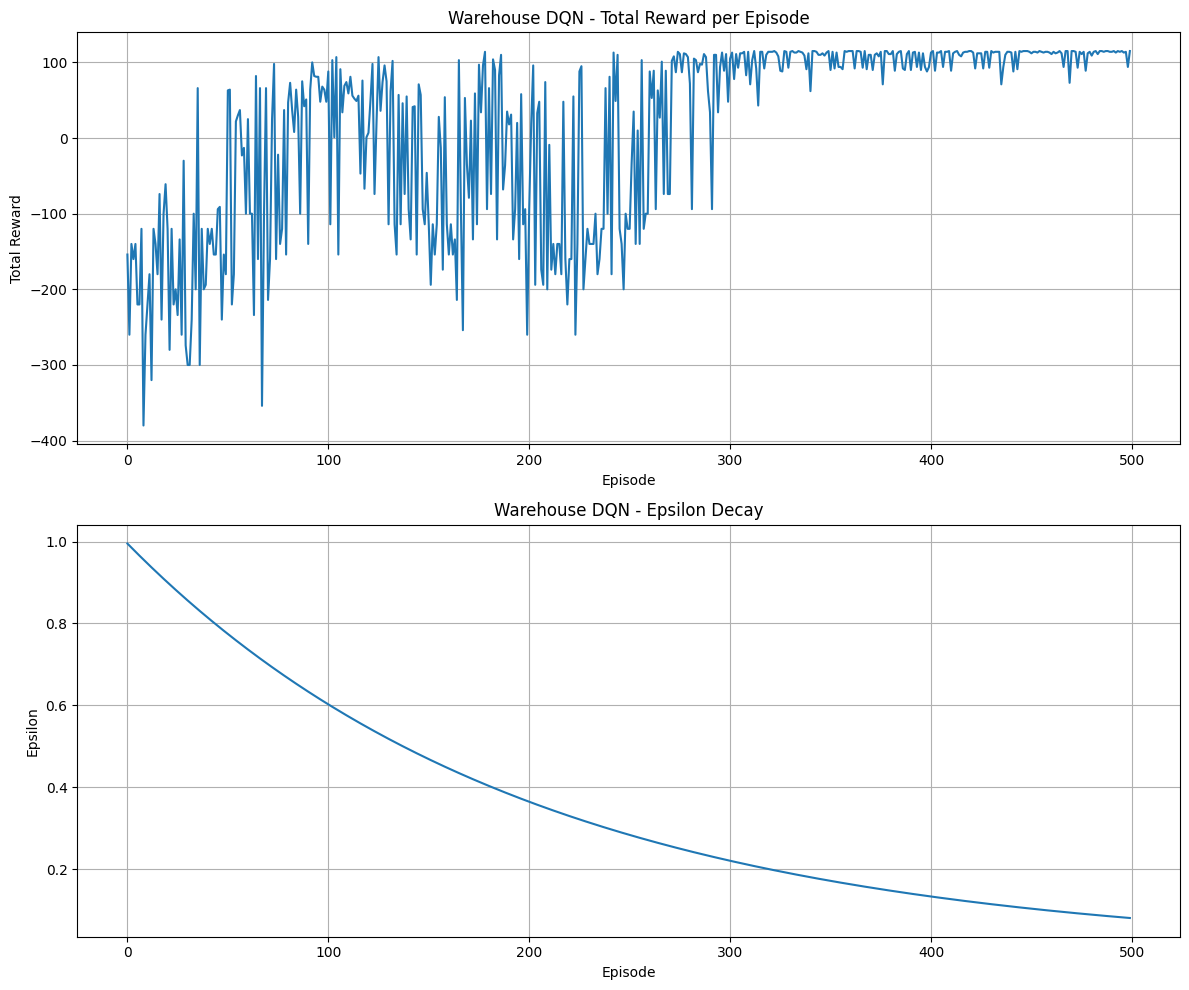

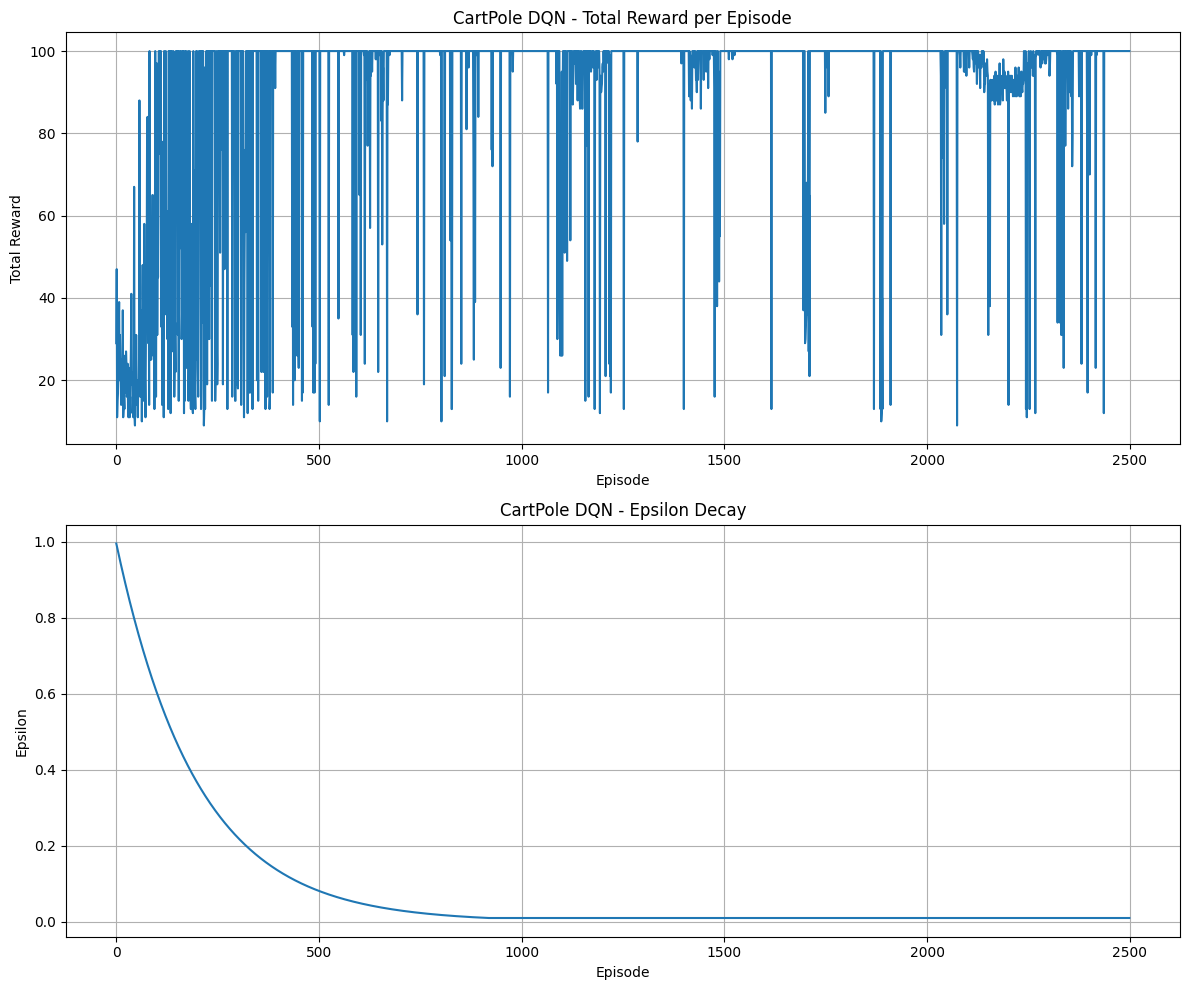

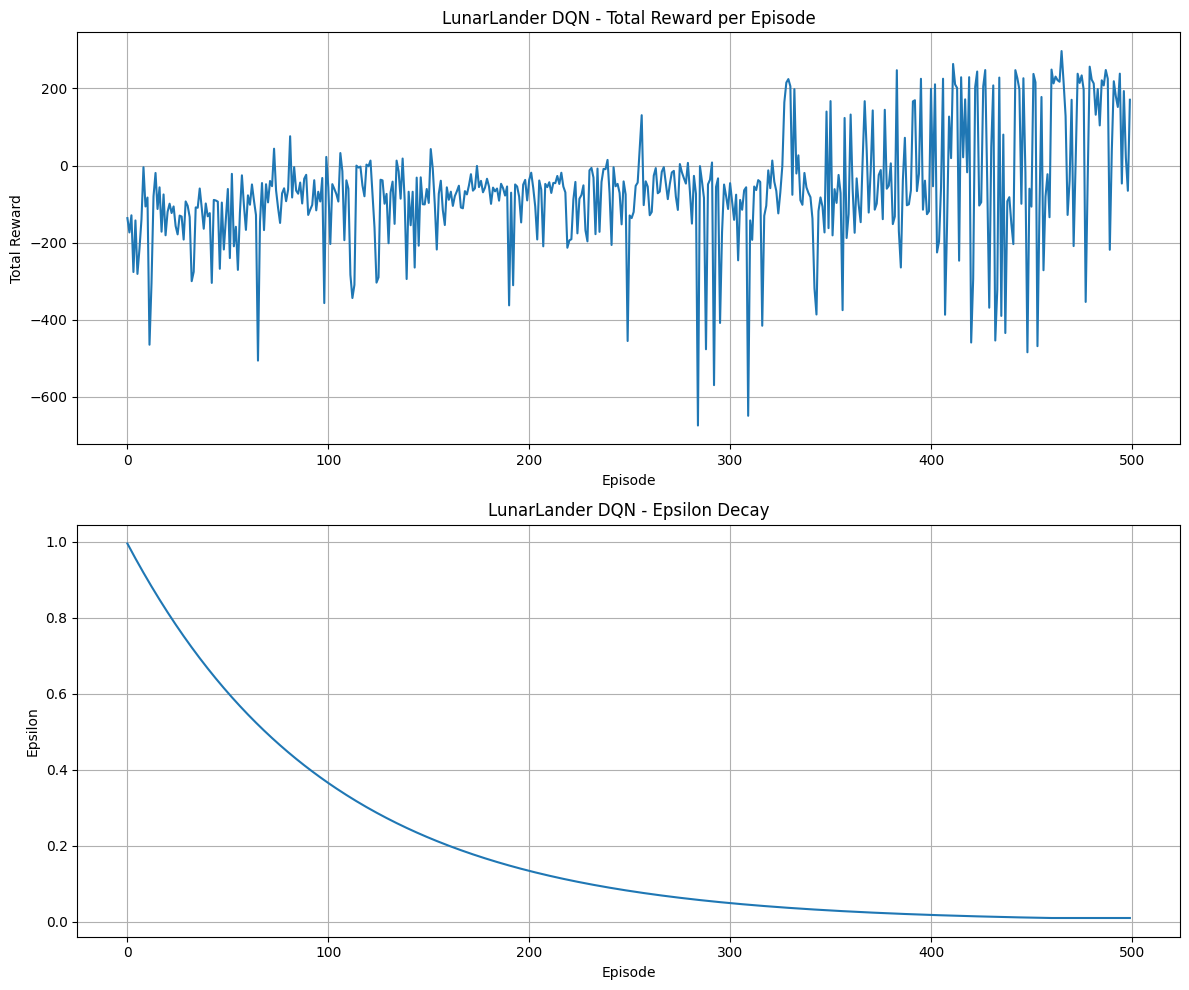

In [18]:
plot_training_results(rewards, epsilons, "Warehouse DQN")
plot_training_results(cartpole_rewards, cartpole_epsilons, "CartPole DQN")
plot_training_results(lander_rewards, lander_epsilons, "LunarLander DQN")


In [20]:
# Save LunarLander model weights
torch.save(lander_agent20.policy_net.state_dict(), "dqn_LunarLander_weights.pth")
